# Bibliotekos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy import stats

from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import Lasso

# Duomenys

In [2]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
data['observationTime'] = pd.to_datetime(data['observationTime'])
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed'],
      dtype='object')

In [3]:
data = data.drop(columns=['BrO_Error', 'NO2_Error', 'O3_Error', 't2m'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

In [4]:
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'NO2', 'O3', 'pm10', 'pm2p5', 'sia',
       'nmvoc', 'dust', 'nh3', 'pans', 'tp', 'airTemperature',
       'seaLevelPressure', 'relativeHumidity', 'missforest_precipitation',
       'xgb_cloudCover', 'feelsLikeTemperature_fixed', 'windSpeed_fixed',
       'windGust_fixed', 'windDirection_fixed', 'month', 'day_of_year',
       'day_of_week'],
      dtype='object')

In [5]:
data.head(5)

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,NO2,O3,...,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,month,day_of_year,day_of_week
0,2018-07-01,-1.016247,0.000075,0.000062,0.000193,22057.926,1136.782022,4.376100e+13,3.627587e+15,332.670633,...,72.791667,9.1,89.375000,10.933333,3.762500,13.9,356.0,7,182,6
1,2018-07-02,-0.800622,0.000079,0.000066,0.000196,22067.760,1229.531736,3.946727e+13,3.795988e+15,339.679410,...,94.000000,11.9,91.500000,10.429167,2.516667,7.0,327.0,7,183,0
2,2018-07-03,-0.621235,0.000077,0.000062,0.000203,19219.670,1314.680602,4.465846e+13,4.526218e+15,361.533268,...,90.041667,10.0,89.375000,13.387500,2.537500,8.3,271.0,7,184,1
3,2018-07-04,-0.659180,0.000072,0.000065,0.000146,19219.450,1824.427700,4.888972e+13,4.149200e+15,343.308865,...,88.291667,13.9,88.333333,13.591667,2.358333,8.7,288.0,7,185,2
4,2018-07-05,-1.010234,0.000079,0.000067,0.000198,19218.373,1257.064200,4.093649e+13,3.959891e+15,311.500626,...,70.208333,0.0,66.000000,16.291667,1.283333,6.1,293.0,7,186,3


# Random Forest realizacija

## Požymių sukūrimas

### Vėlavimai

In [6]:
def lags_fun(column_name, lag_value, data):
    
    new_col_name = f"{column_name}_lag-{lag_value}"
    data.loc[:, new_col_name] = data[column_name].shift(lag_value)

In [7]:
lags_info = {
    # DALELES
    'absorbing_aerosol_index': [8, 19],
    'NO2_column_number_density': [1, 2, 3],
    'stratospheric_NO2_column_number_density': [1, 3, 7],
    'NO2_slant_column_number_density': [1, 2],
    'tropopause_pressure': [1],
    'H2O_column_number_density': [1, 2],
    'NO2': [1, 4, 9],
    'dust': [1, 4],
    'sia': [11],
    'pm2p5': [1, 11],
    'pans': [10, 18],
    'nmvoc': [1, 2],
    'nh3': [1, 11],
    'pm10': [1, 11],

    # METEO
    'airTemperature': [1, 3, 9, 10],
    'seaLevelPressure': [1, 2],
    'relativeHumidity': [1, 2],
    'xgb_cloudCover': [1, 2],
    'windSpeed_fixed': [1, 2, 3],
    'windGust_fixed': [1, 2],
    'windDirection_fixed': [4, 10]
}

for col, lags in lags_info.items():
    if isinstance(lags, list):
        for lag in lags:
            lags_fun(col, lag, data)
    else:
        lags_fun(col, lags, data)

In [8]:
data['target_precipitation'] = data['missforest_precipitation'].shift(-1)

### Rolling window

In [9]:
def rolling_window_fun(column_name, window_value, data):

    new_col_name = f"{column_name}_window-{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean().shift(1)

In [10]:
window_info = {
    'absorbing_aerosol_index': [8],
    'NO2_column_number_density': [3, 2],
    'stratospheric_NO2_column_number_density': [3, 5, 7],
    'NO2_slant_column_number_density': [2],
    'tropopause_pressure': [1],
    'H2O_column_number_density': [2],
    'NO2': [3, 5, 7],
    'dust': [4, 6, 8],
    'sia': [11],
    'pm2p5': [11],
    'pans': [10],
    'nmvoc': [3, 5],
    'nh3': [2, 4],
    'pm10': [5]
}

for col, windows in window_info.items():
    if isinstance(windows, list):
        for window in windows:
            rolling_window_fun(col, window, data)
    else:
        rolling_window_fun(col, windows, data)

In [11]:
data_clean = data.dropna()

In [12]:
data_clean.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'NO2', 'O3', 'pm10', 'pm2p5', 'sia',
       'nmvoc', 'dust', 'nh3', 'pans', 'tp', 'airTemperature',
       'seaLevelPressure', 'relativeHumidity', 'missforest_precipitation',
       'xgb_cloudCover', 'feelsLikeTemperature_fixed', 'windSpeed_fixed',
       'windGust_fixed', 'windDirection_fixed', 'month', 'day_of_year',
       'day_of_week', 'absorbing_aerosol_index_lag-8',
       'absorbing_aerosol_index_lag-19', 'NO2_column_number_density_lag-1',
       'NO2_column_number_density_lag-2', 'NO2_column_number_density_lag-3',
       'stratospheric_NO2_column_number_density_lag-1',
       'stratospheric_NO2_column_number_density_lag-3',
       'stratospheric_NO2_column_number_density_lag-7',
       'NO2_slant_column_number_density_lag-1',
       'NO2_sla

## Požymių atrinkimas ir aibių sudarymas

### Aibių sudarymas I

In [13]:
train_end = '2024-02-01'
val_end = '2025-02-01'

train = data_clean[data_clean['observationTime'] < train_end]
val = data_clean[(data_clean['observationTime'] >= train_end) & (data_clean['observationTime'] <= val_end)]
test  = data_clean[data_clean['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2022, 100), nuo 2018-07-20 00:00:00 iki 2024-01-31 00:00:00
Val: (367, 100), nuo 2024-02-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 100),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


### Požymiai atrinkti pagal LASSO

In [14]:
target = 'target_precipitation'
selected_features = Lasso.select_features_lasso(train.drop(columns=['observationTime']), target)

Pradinis požymių skaičius: 98
Išlikusių požymių skaičius: 31
Geriausias lambda (alpha): 0.0501
Pašalinti požymiai: ['xgb_cloudCover_lag-2', 'O3', 'pm10_lag-11', 'feelsLikeTemperature_fixed', 'pm2p5_window-11', 'absorbing_aerosol_index_window-8', 'NO2_window-7', 'day_of_year', 'relativeHumidity', 'NO2', 'pm10_window-5', 'NO2_column_number_density_window-2', 'dust_lag-4', 'NO2_column_number_density_lag-1', 'NO2_lag-9', 'month', 'windSpeed_fixed_lag-3', 'absorbing_aerosol_index', 'day_of_week', 'pm2p5_lag-11', 'airTemperature', 'sia_window-11', 'stratospheric_NO2_column_number_density', 'windSpeed_fixed_lag-2', 'stratospheric_NO2_column_number_density_window-7', 'windSpeed_fixed_lag-1', 'pans_window-10', 'stratospheric_NO2_column_number_density_lag-7', 'H2O_column_number_density_window-2', 'NO2_lag-4', 'sia', 'dust_lag-1', 'airTemperature_lag-10', 'windSpeed_fixed', 'absorbing_aerosol_index_lag-19', 'airTemperature_lag-1', 'dust_window-4', 'NO2_column_number_density_lag-3', 'H2O_column_nu

In [15]:
selected_features

['NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'pm10',
 'pm2p5',
 'nmvoc',
 'nh3',
 'tp',
 'seaLevelPressure',
 'xgb_cloudCover',
 'windDirection_fixed',
 'NO2_slant_column_number_density_lag-1',
 'tropopause_pressure_lag-1',
 'H2O_column_number_density_lag-1',
 'sia_lag-11',
 'pans_lag-10',
 'pans_lag-18',
 'nmvoc_lag-2',
 'nh3_lag-11',
 'pm10_lag-1',
 'seaLevelPressure_lag-2',
 'relativeHumidity_lag-2',
 'xgb_cloudCover_lag-1',
 'windDirection_fixed_lag-4',
 'windDirection_fixed_lag-10',
 'NO2_slant_column_number_density_window-2',
 'tropopause_pressure_window-1',
 'dust_window-8',
 'nh3_window-2',
 'nh3_window-4']

In [16]:
data_clean = data_clean[selected_features + ['observationTime', 'target_precipitation']].copy()

### Aibių sudarymas II

In [17]:
train_end = '2024-02-01'
val_end = '2025-02-01'

train = data_clean[data_clean['observationTime'] < train_end]
val = data_clean[(data_clean['observationTime'] >= train_end) & (data_clean['observationTime'] <= val_end)]
test  = data_clean[data_clean['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2022, 33), nuo 2018-07-20 00:00:00 iki 2024-01-31 00:00:00
Val: (367, 33), nuo 2024-02-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 33),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


In [18]:
target = 'target_precipitation'
drop_cols = ['observationTime', target]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_val = val.drop(columns=drop_cols)
y_val = val[target]

X_test = test.drop(columns=drop_cols)
y_test = test[target]

### Realizacija

In [19]:
X_train.columns

Index(['NO2_column_number_density', 'NO2_slant_column_number_density',
       'tropopause_pressure', 'H2O_column_number_density', 'pm10', 'pm2p5',
       'nmvoc', 'nh3', 'tp', 'seaLevelPressure', 'xgb_cloudCover',
       'windDirection_fixed', 'NO2_slant_column_number_density_lag-1',
       'tropopause_pressure_lag-1', 'H2O_column_number_density_lag-1',
       'sia_lag-11', 'pans_lag-10', 'pans_lag-18', 'nmvoc_lag-2', 'nh3_lag-11',
       'pm10_lag-1', 'seaLevelPressure_lag-2', 'relativeHumidity_lag-2',
       'xgb_cloudCover_lag-1', 'windDirection_fixed_lag-4',
       'windDirection_fixed_lag-10',
       'NO2_slant_column_number_density_window-2',
       'tropopause_pressure_window-1', 'dust_window-8', 'nh3_window-2',
       'nh3_window-4'],
      dtype='object')

In [20]:
rf_default = RandomForestRegressor(random_state=123)
rf_default.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
rf_default_pred_val = rf_default.predict(X_val)

### Metrikos

In [22]:
def metrics_fun(y_val_true, rf_pred_val):
    print(f'R^2:  {r2_score(y_val_true, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val_true, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val_true, rf_pred_val))}')
    # print(f'MAPE: {mean_absolute_percentage_error(y_val_true, rf_pred_val)}')

    corr, p_value = stats.spearmanr(y_val_true, rf_pred_val)
    print(f"r_s:  {corr}")

Globalaus modelio paklaidos - validavimo aibė

In [23]:
metrics_fun(y_val, X_val['tp'])

R^2:  0.5026324749895323
MAE:  1.4685700168000633
RMSE: 3.40532484561435
r_s:  0.7378103776223065


RF modelio paklaidos

In [24]:
metrics_fun(y_val, rf_default_pred_val)

R^2:  0.4009423989350701
MAE:  1.5618947685730957
RMSE: 3.737266999388196
r_s:  0.7069503488910721


In [25]:
len(rf_default_pred_val)

367

### Vizualizacija

In [26]:
# plot_df = val[['observationTime', 'target_precipitation']].copy()
# plot_df['prediction'] = rf_default_pred_val
# plot_df = plot_df.sort_values('observationTime')

plot_df = val.loc[y_val.index, ['observationTime', 'target_precipitation', 'tp']].copy()
plot_df['prediction'] = rf_default_pred_val
plot_df = plot_df.sort_values('observationTime')

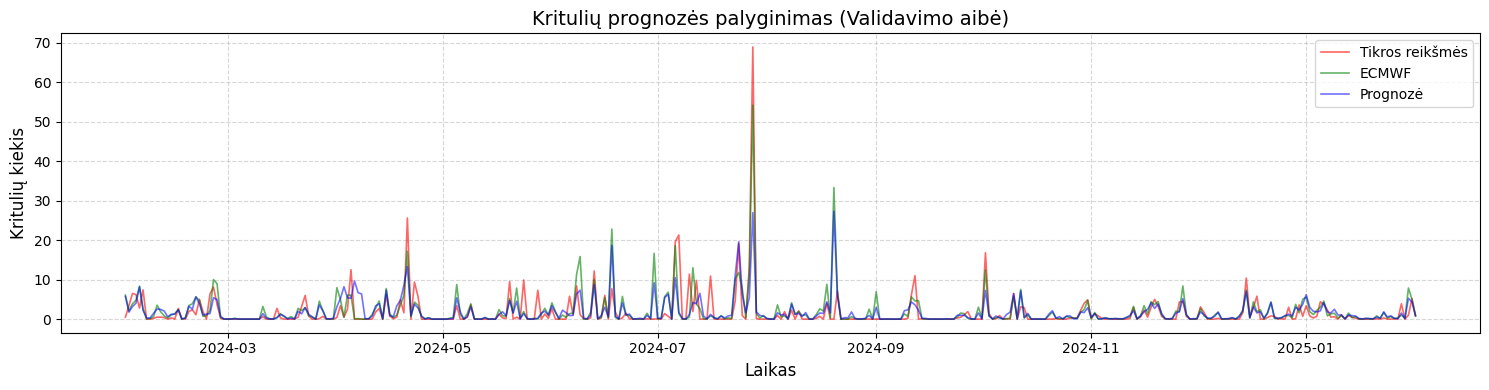

In [27]:
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(plot_df['observationTime'], plot_df['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(plot_df['observationTime'], plot_df['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(plot_df['observationTime'], plot_df['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.55)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

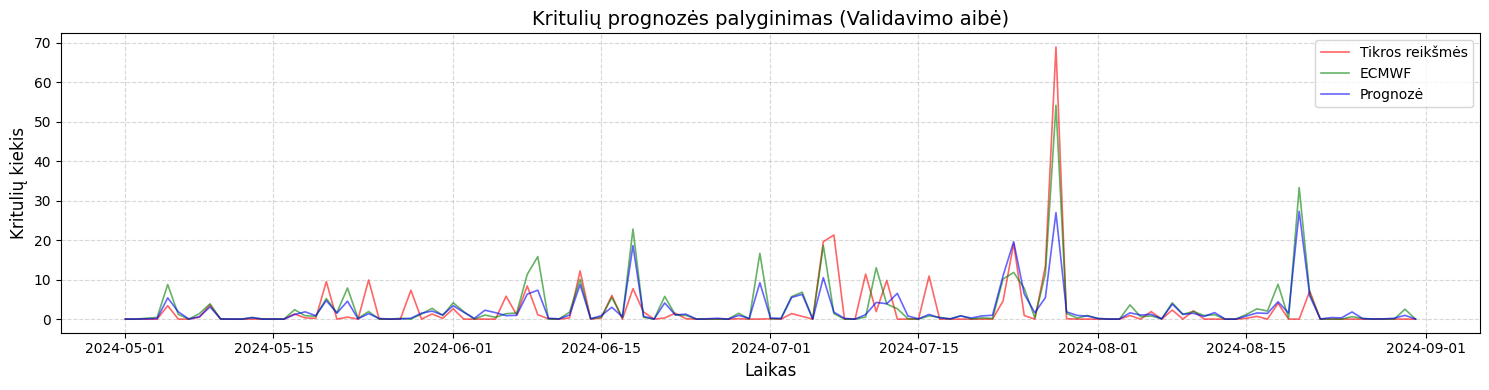

In [28]:
short_period = plot_df[(plot_df['observationTime'] >= '2024-05-01') & (plot_df['observationTime'] < '2024-09-01')]

fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(short_period['observationTime'], short_period['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.6)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

### Požymių reikšmingumas

In [29]:
rf_default_importances = rf_default.feature_importances_
rf_default_importances

array([0.00795902, 0.00829167, 0.01328054, 0.0322673 , 0.0372974 ,
       0.01112675, 0.00872862, 0.00987112, 0.50851815, 0.01029206,
       0.01098494, 0.02724316, 0.00726055, 0.02330774, 0.04962189,
       0.00917754, 0.01025162, 0.01013567, 0.0108941 , 0.02752112,
       0.01247519, 0.01638227, 0.016224  , 0.01114455, 0.00779268,
       0.01998823, 0.0074118 , 0.01671743, 0.02464738, 0.02094024,
       0.01224528])

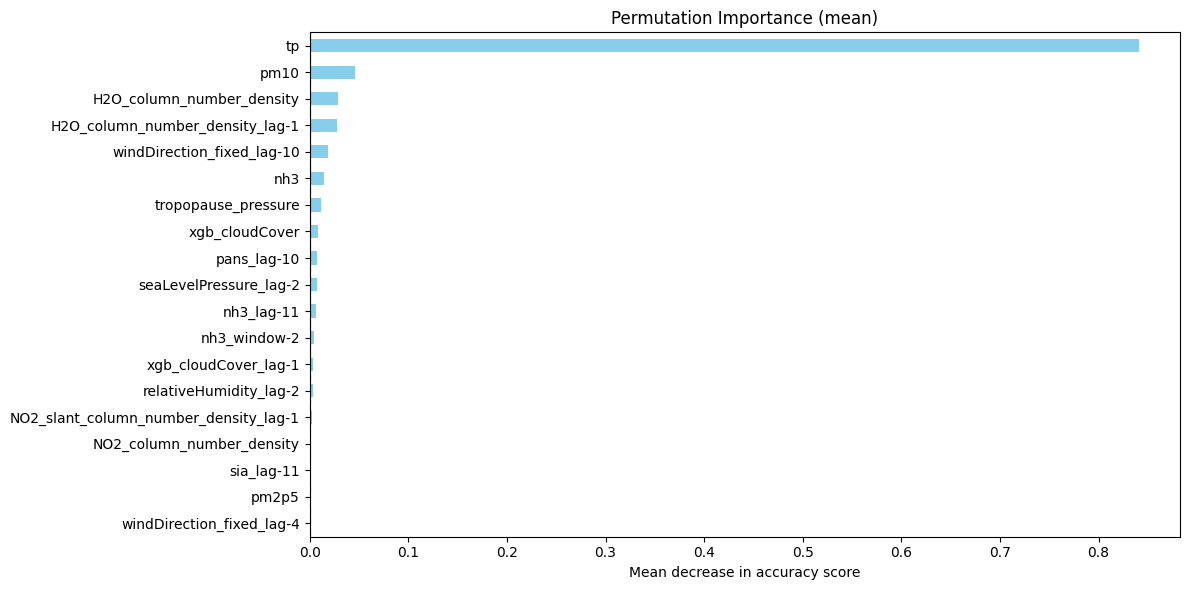

In [30]:
result = permutation_importance(rf_default, X_val, y_val, n_repeats=5, random_state=123)
sorted_importances_idx = result.importances_mean.argsort()
importances_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_val.columns[sorted_importances_idx]
)

forest_importances = pd.Series(result.importances_mean, index=X_val.columns)
forest_importances = forest_importances[forest_importances > 0]
forest_importances = forest_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances.plot.barh(ax=ax, color='skyblue')
ax.set_title("Permutation Importance (mean)")
ax.set_xlabel("Mean decrease in accuracy score")
ax.axvline(x=0, color="k", linestyle="--")

fig.tight_layout()
plt.show()

In [31]:
forest_importances

windDirection_fixed_lag-4                0.000502
pm2p5                                    0.000565
sia_lag-11                               0.001673
NO2_column_number_density                0.001778
NO2_slant_column_number_density_lag-1    0.002601
relativeHumidity_lag-2                   0.003044
xgb_cloudCover_lag-1                     0.003476
nh3_window-2                             0.004156
nh3_lag-11                               0.006593
seaLevelPressure_lag-2                   0.007120
pans_lag-10                              0.007460
xgb_cloudCover                           0.008488
tropopause_pressure                      0.011340
nh3                                      0.014073
windDirection_fixed_lag-10               0.018824
H2O_column_number_density_lag-1          0.028008
H2O_column_number_density                0.028629
pm10                                     0.046297
tp                                       0.840547
dtype: float64

## Optimalių hiperparametrų atrinkimas

### Hiperparametrų kitimas

In [32]:
# from sklearn.model_selection import validation_curve

In [33]:
# params = [
#     {"name": "n_estimators", "range": [10, 20, 50, 100, 200, 350, 400, 500]},
#     {"name": "max_depth", "range": [2, 4, 8, 16, 32, 64, 128]},
#     {"name": "max_features", "range": [0.05, 0.01,  0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]},
#     {"name": "min_samples_split", "range": [2, 5, 10, 20, 50]}
# ]


# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# axes = axes.flatten()
# tscv = TimeSeriesSplit(n_splits=5)

# for i, p in enumerate(params):

#     rf = RandomForestRegressor(random_state=123)
    
#     train_scores, test_scores = validation_curve(
#         rf, X_train, y_train, 
#         param_name=p["name"], param_range=p["range"],
#         cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1
#     )

#     train_mean = np.mean(train_scores, axis=1)
#     test_mean = np.mean(test_scores, axis=1)
    
#     axes[i].plot(p["range"], train_mean, label="Mokymo", marker='o', color='blue', markersize=3)
#     axes[i].plot(p["range"], test_mean, label="Validacijos", marker='s', color='orange', markersize=3)

#     axes[i].set_xlabel(f"Parametro '{p['name']}' reikšmė")
#     axes[i].set_ylabel("neg_mean_squared_error")
#     axes[i].grid(True, linestyle='--', alpha=0.7)
#     axes[i].legend()

# plt.tight_layout()
# plt.show()

In [34]:
# param_grid = {
#     'n_estimators': [50, 100, 150, 200],
#     'max_depth': [None, 4, 16, 32, 64], 
#     'min_samples_split': [2, 4, 6, 8],
#     'min_samples_leaf': [1, 2, 3, 4]
# }

# rf = RandomForestRegressor(random_state=123)

# tscv = TimeSeriesSplit(n_splits=5)
# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=tscv)
# grid_search.fit(X_train, y_train)

# best_model = grid_search.best_estimator_

# print(f"Geriausi parametrai: {grid_search.best_params_}")
# print(f"Tikslumas: {grid_search.best_score_:.4f}")

In [35]:
# rf_h = RandomForestRegressor(max_depth = 4, n_estimators = 200, random_state=123)
# rf_h.fit(X_train, y_train)
# rf_h_pred_val = rf_h.predict(X_val)

# metrics_fun(y_val, rf_h_pred_val)

In [36]:
# rf_h = RandomForestRegressor(max_depth = 16, n_estimators = 50, min_samples_leaf = 3, min_samples_split = 2, random_state=123)
# rf_h.fit(X_train, y_train)
# rf_h_pred_val = rf_h.predict(X_val)

# metrics_fun(y_val, rf_h_pred_val)

### Vizualizacija

In [37]:
# plot_df = val[['observationTime', 'target_precipitation']].copy()
# plot_df['prediction'] = rf_h_pred_val
# plot_df = plot_df.sort_values('observationTime')

In [38]:
# fig, ax1 = plt.subplots(figsize=(15, 4))
# ax1.plot(plot_df['observationTime'], plot_df['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
# ax1.plot(plot_df['observationTime'], plot_df['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.6)
# ax1.legend(loc='upper right', fontsize=10, frameon=True)
# ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
# ax1.set_xlabel("Laikas", fontsize=12)
# ax1.set_ylabel("Kritulių kiekis", fontsize=12)
# ax1.grid(True, linestyle='--', alpha=0.5)

# fig.tight_layout()
# plt.show()